# MGSC 416 — Semester Project

## Optimising cafe operations through demand forecasting and inventory planning

**Dataset:** Kaggle cafe transaction data (9,741 transactions, Jan–Dec 2023)  
**Tools:** pandas, numpy, matplotlib, seaborn, statsmodels, gurobipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

---

# Section 1 — Data loading and cleaning (Person 1)

Load both CSVs, inspect the raw data, then clean:
1. Drop rows with invalid item names ("unknown", "error")
2. Fix Total Spent mismatches where Quantity × Price Per Unit ≠ Total Spent
3. Document price inconsistencies per item

### 1.1 Load raw data

In [2]:
raw = pd.read_csv('Cleaned_DataSet.csv', parse_dates=['Transaction Date'])
holidays = pd.read_csv('holidays.csv', parse_dates=['date'])

print(f'Raw transactions: {len(raw):,} rows, {raw.shape[1]} columns')
print(f'Holidays:         {len(holidays):,} rows')
raw.head(10)

Raw transactions: 9,741 rows, 6 columns
Holidays:         205 rows


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,cookie,4.0,1.0,8.0,2023-07-19
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11
5,TXN_2602893,smoothie,5.0,4.0,20.0,2023-03-31
6,TXN_4433211,unknown,3.0,3.0,9.0,2023-10-06
7,TXN_6699534,sandwich,4.0,4.0,16.0,2023-10-28
8,TXN_4717867,juice,5.0,3.0,15.0,2023-07-28
9,TXN_2064365,sandwich,5.0,4.0,20.0,2023-12-31


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9741 entries, 0 to 9740
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9741 non-null   object        
 1   Item              9741 non-null   object        
 2   Quantity          9741 non-null   float64       
 3   Price Per Unit    9741 non-null   float64       
 4   Total Spent       9741 non-null   float64       
 5   Transaction Date  9741 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 456.7+ KB


In [4]:
raw.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9741.000000,9741.000000,9741.000000,9741
mean,2.977312,2.901499,8.449287,2023-06-25 04:12:29.491838720
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-19 00:00:00
50%,3.000000,3.000000,8.000000,2023-06-23 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-27 00:00:00
max,5.000000,5.000000,20.000000,2023-12-31 00:00:00
std,1.366510,1.217124,5.307016,NaN


### 1.2 Inspect item distribution and identify invalid items

In [5]:
print('Item value counts (raw):')
print(raw['Item'].value_counts())
print(f"\nRows with 'unknown': {(raw['Item'] == 'unknown').sum()}")
print(f"Rows with 'error':   {(raw['Item'] == 'error').sum()}")
print(f'Total invalid:       {((raw["Item"] == "unknown") | (raw["Item"] == "error")).sum()}')

Item value counts (raw):
Item
juice       1499
coffee      1165
cake        1139
sandwich    1131
smoothie    1096
cookie      1092
tea         1089
salad        910
unknown      337
error        283
Name: count, dtype: int64

Rows with 'unknown': 337
Rows with 'error':   283
Total invalid:       620


### 1.3 Drop invalid items

Rows labelled "unknown" and "error" have wildly inconsistent prices and represent corrupted data. We drop all 620 of them.

In [6]:
valid_items = ['coffee', 'tea', 'juice', 'smoothie', 'cake', 'cookie', 'sandwich', 'salad']
df = raw[raw['Item'].isin(valid_items)].copy()
print(f'Rows after dropping invalid items: {len(df):,} (removed {len(raw) - len(df):,})')

Rows after dropping invalid items: 9,121 (removed 620)


### 1.4 Fix Total Spent mismatches

Check how many rows have `Total Spent ≠ Quantity × Price Per Unit` and recalculate.

In [7]:
expected_total = df['Quantity'] * df['Price Per Unit']
mismatch_mask = ~np.isclose(df['Total Spent'], expected_total)
print(f'Mismatched rows: {mismatch_mask.sum():,} out of {len(df):,} ({mismatch_mask.mean():.1%})')

print('\nExamples of mismatched rows:')
df.loc[mismatch_mask].head(10)

Mismatched rows: 1,083 out of 9,121 (11.9%)

Examples of mismatched rows:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
2,TXN_4271903,cookie,4.0,1.0,8.0,2023-07-19
19,TXN_3522028,smoothie,3.0,4.0,20.0,2023-04-04
24,TXN_7958992,smoothie,3.0,4.0,8.0,2023-12-13
41,TXN_6650263,tea,2.0,1.5,8.0,2023-01-10
52,TXN_5522862,cookie,3.0,1.0,2.0,2023-03-19
54,TXN_2080895,cake,3.0,3.0,3.0,2023-04-19
62,TXN_4987129,sandwich,3.0,3.0,8.0,2023-10-20
63,TXN_8501819,juice,3.0,3.0,6.0,2023-03-30
65,TXN_8427104,salad,2.0,3.0,10.0,2023-10-27
82,TXN_8035512,tea,3.0,3.0,4.5,2023-10-29


In [8]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']
print('Total Spent recalculated as Quantity × Price Per Unit.')
print(f'Remaining mismatches: {(~np.isclose(df["Total Spent"], df["Quantity"] * df["Price Per Unit"])).sum()}')

Total Spent recalculated as Quantity × Price Per Unit.
Remaining mismatches: 0


### 1.5 Investigate price inconsistencies

Some items have multiple price points. This could indicate different sizes or price changes.

In [9]:
price_summary = (
    df.groupby('Item')['Price Per Unit']
    .agg(['nunique', 'min', 'max', lambda x: sorted(x.unique().tolist())])
)
price_summary.columns = ['n_prices', 'min_price', 'max_price', 'price_values']
price_summary = price_summary.sort_values('n_prices', ascending=False)
print('Price variants per item:')
price_summary

Price variants per item:


,n_prices,min_price,max_price,price_values
Item,,,,
juice,6,1.0,5.0,"[1.0, 1.5, 2.0, 3.0, 4.0, 5.0]"
coffee,2,2.0,3.0,"[2.0, 3.0]"
cookie,2,1.0,3.0,"[1.0, 3.0]"
salad,2,3.0,5.0,"[3.0, 5.0]"
sandwich,2,3.0,4.0,"[3.0, 4.0]"
smoothie,2,3.0,4.0,"[3.0, 4.0]"
tea,2,1.5,3.0,"[1.5, 3.0]"
cake,1,3.0,3.0,[3.0]


In [10]:
for item in df['Item'].unique():
    item_prices = df[df['Item'] == item]['Price Per Unit'].value_counts().sort_index()
    if len(item_prices) > 1:
        print(f'\n{item}:')
        for price, count in item_prices.items():
            print(f'  ${price:.2f} — {count:,} transactions')


coffee:
  $2.00 — 1,108 transactions
  $3.00 — 57 transactions

cookie:
  $1.00 — 1,026 transactions
  $3.00 — 66 transactions

salad:
  $3.00 — 51 transactions
  $5.00 — 859 transactions

smoothie:
  $3.00 — 60 transactions
  $4.00 — 1,036 transactions

sandwich:
  $3.00 — 49 transactions
  $4.00 — 1,082 transactions

juice:
  $1.00 — 38 transactions
  $1.50 — 33 transactions
  $2.00 — 39 transactions
  $3.00 — 1,274 transactions
  $4.00 — 82 transactions
  $5.00 — 33 transactions

tea:
  $1.50 — 1,023 transactions
  $3.00 — 66 transactions


**Observation:** Items with two price points likely represent size variants (e.g. small vs large coffee). We keep both variants and note this as a feature that could be explored further.

### 1.6 Cleaned dataset summary

In [11]:
print(f'Cleaned dataset: {len(df):,} rows, {df.shape[1]} columns')
print(f'Date range: {df["Transaction Date"].min().date()} to {df["Transaction Date"].max().date()}')
print(f'Valid items: {sorted(df["Item"].unique().tolist())}')
print(f'\nColumn types:')
print(df.dtypes)
df.head()

Cleaned dataset: 9,121 rows, 6 columns
Date range: 2023-01-01 to 2023-12-31
Valid items: ['cake', 'coffee', 'cookie', 'juice', 'salad', 'sandwich', 'smoothie', 'tea']

Column types:
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Transaction Date    datetime64[ns]
dtype: object


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16
2,TXN_4271903,cookie,4.0,1.0,4.0,2023-07-19
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11


---

# Section 2 — Feature engineering (Person 2)

Derive all analytical features from the transaction dates and the holidays calendar. No external data sources used.

**Features created:**
- Temporal: day_of_week, day_name, is_weekend, month, season, week_number, is_month_start, is_month_end
- Holiday: is_holiday, days_to_next_holiday
- Item: item_category (drinks/food), is_hot_drink

### 2.1 Temporal features

In [12]:
df['day_of_week'] = df['Transaction Date'].dt.dayofweek
df['day_name'] = df['Transaction Date'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['Transaction Date'].dt.month
df['week_number'] = df['Transaction Date'].dt.isocalendar().week.astype(int)
df['is_month_start'] = df['Transaction Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Transaction Date'].dt.is_month_end.astype(int)

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
df['season'] = df['month'].map(season_map)

print('Temporal features added.')
df[['Transaction Date', 'day_of_week', 'day_name', 'is_weekend', 'month', 'season', 'week_number']].head(10)

Temporal features added.


,Transaction Date,day_of_week,day_name,is_weekend,month,season,week_number
0,2023-09-08,4,Friday,0,9,Autumn,36
1,2023-05-16,1,Tuesday,0,5,Spring,20
2,2023-07-19,2,Wednesday,0,7,Summer,29
3,2023-04-27,3,Thursday,0,4,Spring,17
4,2023-06-11,6,Sunday,1,6,Summer,23
5,2023-03-31,4,Friday,0,3,Spring,13
7,2023-10-28,5,Saturday,1,10,Autumn,43
8,2023-07-28,4,Friday,0,7,Summer,30
9,2023-12-31,6,Sunday,1,12,Winter,52
10,2023-02-06,0,Monday,0,2,Winter,6


### 2.2 Holiday features

Merge the Canadian holidays calendar. Create a binary `is_holiday` flag and compute `days_to_next_holiday`.

In [13]:
holidays_2023 = holidays[holidays['date'].dt.year == 2023].copy()
print(f'Holidays in 2023: {len(holidays_2023)}')
holidays_2023

Holidays in 2023: 13


,date,holiday
156,2023-01-02,New Year's Day
157,2023-02-20,Family Day
158,2023-04-07,Good Friday
159,2023-05-22,Victoria Day
160,2023-07-03,Canada Day
161,2023-08-07,Civic Holiday
162,2023-09-04,Labour Day
163,2023-10-09,Thanksgiving
164,2023-12-25,Christmas Day
165,2023-12-26,Boxing Day


In [14]:
holiday_dates = set(holidays_2023['date'].dt.date)
df['is_holiday'] = df['Transaction Date'].dt.date.isin(holiday_dates).astype(int)

holiday_dates_sorted = sorted(holidays_2023['date'].tolist())

def days_to_next_holiday(date, holiday_list):
    future = [h for h in holiday_list if h >= date]
    if not future:
        return np.nan
    return (future[0] - date).days

df['days_to_next_holiday'] = df['Transaction Date'].apply(
    lambda d: days_to_next_holiday(d, holiday_dates_sorted)
)

print(f'Transactions on holidays: {df["is_holiday"].sum():,}')
print(f'days_to_next_holiday range: {df["days_to_next_holiday"].min():.0f} – {df["days_to_next_holiday"].max():.0f}')
df[['Transaction Date', 'is_holiday', 'days_to_next_holiday']].head(10)

Transactions on holidays: 289
days_to_next_holiday range: 0 – 76


,Transaction Date,is_holiday,days_to_next_holiday
0,2023-09-08,0,31.0
1,2023-05-16,0,6.0
2,2023-07-19,0,19.0
3,2023-04-27,0,25.0
4,2023-06-11,0,22.0
5,2023-03-31,0,7.0
7,2023-10-28,0,58.0
8,2023-07-28,0,10.0
9,2023-12-31,0,NaN
10,2023-02-06,0,14.0


### 2.3 Item-derived features

In [15]:
drinks = {'coffee', 'tea', 'juice', 'smoothie'}
hot_drinks = {'coffee', 'tea'}

df['item_category'] = df['Item'].apply(lambda x: 'drinks' if x in drinks else 'food')
df['is_hot_drink'] = df['Item'].apply(lambda x: 1 if x in hot_drinks else 0)

print('Item category distribution:')
print(df['item_category'].value_counts())
print(f'\nHot drink transactions: {df["is_hot_drink"].sum():,}')

Item category distribution:
item_category
drinks    4849
food      4272
Name: count, dtype: int64

Hot drink transactions: 2,254


### 2.4 Final enriched dataset

In [16]:
print(f'Enriched dataset: {len(df):,} rows, {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

Enriched dataset: 9,121 rows, 18 columns

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Transaction Date', 'day_of_week', 'day_name', 'is_weekend', 'month', 'week_number', 'is_month_start', 'is_month_end', 'season', 'is_holiday', 'days_to_next_holiday', 'item_category', 'is_hot_drink']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Transaction Date,day_of_week,day_name,is_weekend,month,week_number,is_month_start,is_month_end,season,is_holiday,days_to_next_holiday,item_category,is_hot_drink
0,TXN_1961373,coffee,2.0,2.0,4.0,2023-09-08,4,Friday,0,9,36,0,0,Autumn,0,31.0,drinks,1
1,TXN_4977031,cake,4.0,3.0,12.0,2023-05-16,1,Tuesday,0,5,20,0,0,Spring,0,6.0,food,0
2,TXN_4271903,cookie,4.0,1.0,4.0,2023-07-19,2,Wednesday,0,7,29,0,0,Summer,0,19.0,food,0
3,TXN_7034554,salad,2.0,5.0,10.0,2023-04-27,3,Thursday,0,4,17,0,0,Spring,0,25.0,food,0
4,TXN_3160411,coffee,2.0,2.0,4.0,2023-06-11,6,Sunday,1,6,23,0,0,Summer,0,22.0,drinks,1


In [17]:
df.to_csv('enriched_dataset.csv', index=False)
print('Saved enriched_dataset.csv')

Saved enriched_dataset.csv


---

# Section 3 — Descriptive analysis and visualisations (Person 1)

Explore the cleaned and enriched dataset to surface patterns that will guide the prediction and optimisation stages.

### 3.1 Summary statistics

In [18]:
print('=== Summary statistics by item ===')
item_stats = (
    df.groupby('Item')
    .agg(
        transactions=('Transaction ID', 'count'),
        avg_quantity=('Quantity', 'mean'),
        avg_price=('Price Per Unit', 'mean'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
)
item_stats

=== Summary statistics by item ===


,transactions,avg_quantity,avg_price,total_revenue,avg_revenue_per_txn
Item,,,,,
sandwich,1131,3.03,3.96,13538.0,11.97
juice,1499,3.01,2.99,13465.5,8.98
smoothie,1096,3.06,3.95,13218.0,12.06
salad,910,2.53,4.89,11279.0,12.39
cake,1139,3.04,3.00,10401.0,9.13
coffee,1165,3.05,2.05,7261.0,6.23
tea,1089,3.05,1.59,5296.5,4.86
cookie,1092,2.98,1.12,3651.0,3.34


In [19]:
print('=== Summary statistics by day of week ===')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = (
    df.groupby('day_name')
    .agg(
        transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .reindex(day_order)
)
day_stats

=== Summary statistics by day of week ===


,transactions,total_revenue,avg_revenue_per_txn
day_name,,,
Monday,1683,14339.5,8.52
Tuesday,1190,10463.0,8.79
Wednesday,1213,10240.5,8.44
Thursday,1255,10847.0,8.64
Friday,1274,10838.5,8.51
Saturday,1228,10430.0,8.49
Sunday,1278,10951.5,8.57


In [20]:
print('=== Summary statistics by season ===')
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_stats = (
    df.groupby('season')
    .agg(
        transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_revenue_per_txn=('Total Spent', 'mean'),
    )
    .round(2)
    .reindex(season_order)
)
season_stats

=== Summary statistics by season ===


,transactions,total_revenue,avg_revenue_per_txn
season,,,
Winter,2557,22263.0,8.71
Spring,2165,18683.5,8.63
Summer,2193,18493.0,8.43
Autumn,2206,18670.5,8.46


### 3.2 Revenue by item

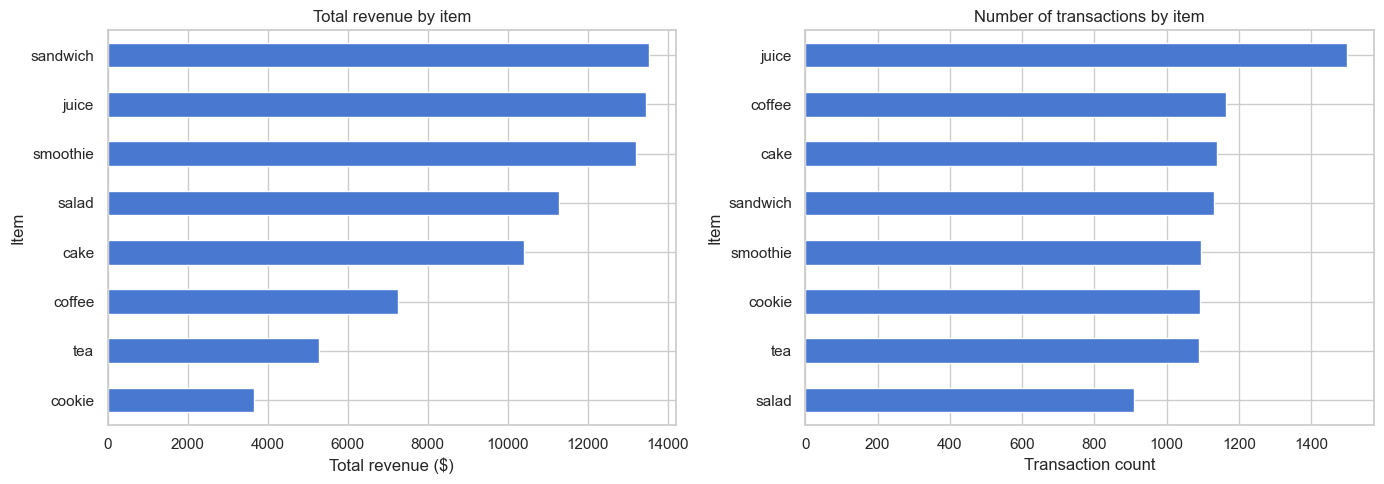

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=True)
item_revenue.plot(kind='barh', ax=axes[0])
axes[0].set_title('Total revenue by item')
axes[0].set_xlabel('Total revenue ($)')

item_counts = df['Item'].value_counts().sort_values(ascending=True)
item_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Number of transactions by item')
axes[1].set_xlabel('Transaction count')

plt.tight_layout()
plt.savefig('fig_revenue_by_item.png', bbox_inches='tight')
plt.show()

### 3.3 Transactions by day of week

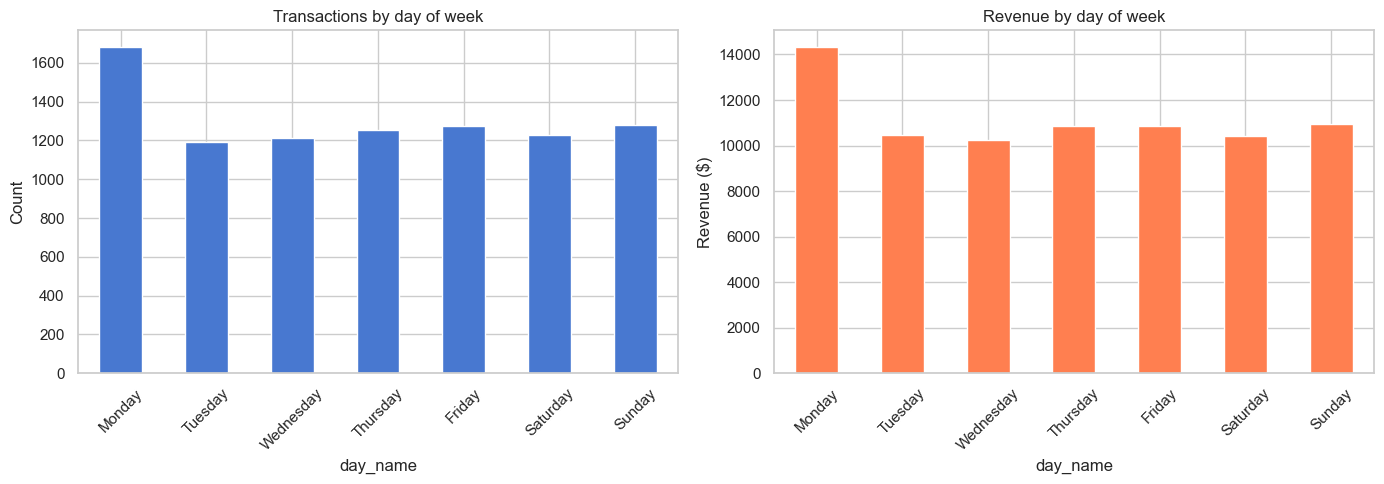

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_txn = df.groupby('day_name')['Transaction ID'].count().reindex(day_order)
day_txn.plot(kind='bar', ax=axes[0])
axes[0].set_title('Transactions by day of week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

day_rev = df.groupby('day_name')['Total Spent'].sum().reindex(day_order)
day_rev.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Revenue by day of week')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_day_of_week.png', bbox_inches='tight')
plt.show()

### 3.4 Weekly revenue over time

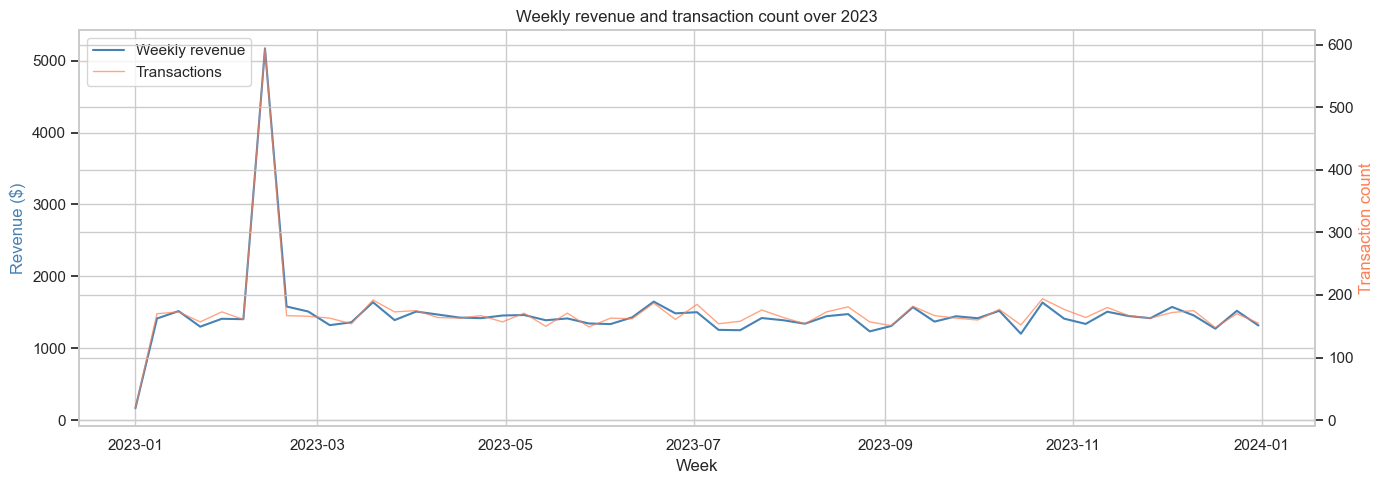

In [23]:
weekly = (
    df.set_index('Transaction Date')
    .resample('W')['Total Spent']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'revenue', 'count': 'transactions'})
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(weekly.index, weekly['revenue'], color='steelblue', linewidth=1.5, label='Weekly revenue')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.set_xlabel('Week')
ax1.set_title('Weekly revenue and transaction count over 2023')

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly['transactions'], color='coral', linewidth=1, alpha=0.7, label='Transactions')
ax2.set_ylabel('Transaction count', color='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_weekly_revenue.png', bbox_inches='tight')
plt.show()

### 3.5 Heatmap: sales by day of week × month

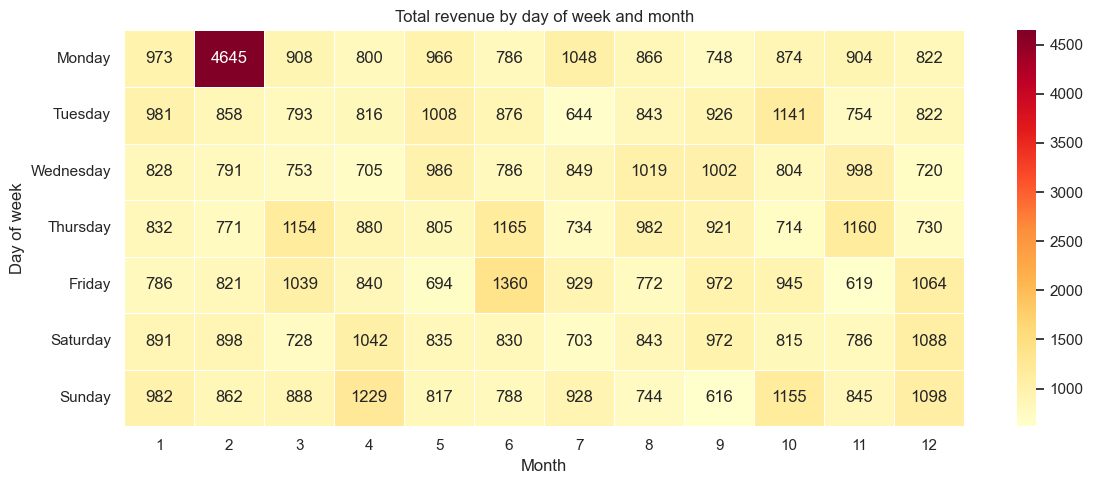

In [24]:
heatmap_data = df.pivot_table(
    values='Total Spent',
    index='day_name',
    columns='month',
    aggfunc='sum'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Total revenue by day of week and month')
plt.ylabel('Day of week')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('fig_heatmap_day_month.png', bbox_inches='tight')
plt.show()

### 3.5.1 Investigation: Monday/February outlier

The heatmap above reveals a striking anomaly — Monday in February has a revenue of $4,645, far exceeding any other cell. Let us investigate whether this is a genuine data point or a data quality issue.

In [25]:
mon_feb = df[(df['day_name'] == 'Monday') & (df['month'] == 2)]
daily_mon_feb = (
    mon_feb.groupby('Transaction Date')
    .agg(transactions=('Transaction ID', 'count'), revenue=('Total Spent', 'sum'))
    .sort_values('revenue', ascending=False)
)
print('Mondays in February — daily breakdown:')
print(daily_mon_feb.to_string())

all_daily = df.groupby('Transaction Date').agg(
    transactions=('Transaction ID', 'count'),
    revenue=('Total Spent', 'sum')
)
mean_rev = all_daily['revenue'].mean()
std_rev = all_daily['revenue'].std()
feb6_rev = all_daily.loc[pd.Timestamp('2023-02-06'), 'revenue']
feb6_txn = all_daily.loc[pd.Timestamp('2023-02-06'), 'transactions']
z_score = (feb6_rev - mean_rev) / std_rev

print(f'\nFeb 6 transactions: {int(feb6_txn)} (normal day mean: {all_daily["transactions"].mean():.0f}, median: {all_daily["transactions"].median():.0f})')
print(f'Feb 6 revenue: ${feb6_rev:.0f} (normal day mean: ${mean_rev:.0f})')
print(f'Z-score: {z_score:.1f} (extreme outlier, >3σ threshold)')
print(f'\nNo duplicate Transaction IDs on Feb 6: {mon_feb["Transaction ID"].is_unique}')

Mondays in February — daily breakdown:
                  transactions  revenue
Transaction Date                       
2023-02-06                 462   4020.5
2023-02-13                  25    217.0
2023-02-27                  26    207.0
2023-02-20                  26    200.5

Feb 6 transactions: 462 (normal day mean: 25, median: 24)
Feb 6 revenue: $4020 (normal day mean: $214)
Z-score: 18.5 (extreme outlier, >3σ threshold)

No duplicate Transaction IDs on Feb 6: True


**Finding:** 2023-02-06 (Monday) has **462 transactions** while a normal day averages ~24. Its z-score of 18.5 makes it an extreme statistical outlier. Despite having unique Transaction IDs (no exact duplicates), the volume is ~19× normal — this is almost certainly a data ingestion error in the Kaggle source dataset where records were incorrectly concentrated onto this single date.

**Decision:** Rather than deleting the entire day (which would create a gap in the time series), we impute Feb 6 with the **average transaction pattern from other winter Mondays**. This preserves the date in our dataset while replacing the anomalous values with representative ones.

In [26]:
winter_mondays = df[
    (df['day_name'] == 'Monday') &
    (df['season'] == 'Winter') &
    (df['Transaction Date'] != pd.Timestamp('2023-02-06'))
]

avg_by_item = (
    winter_mondays
    .groupby(['Transaction Date', 'Item'])
    .agg(txn=('Transaction ID', 'count'), qty=('Quantity', 'mean'), price=('Price Per Unit', 'mean'))
    .reset_index()
    .groupby('Item')
    .agg(avg_txn=('txn', 'mean'), avg_qty=('qty', 'mean'), avg_price=('price', 'mean'))
)

price_mode = winter_mondays.groupby('Item')['Price Per Unit'].agg(lambda x: x.mode().iloc[0])
qty_mode = winter_mondays.groupby('Item')['Quantity'].agg(lambda x: x.mode().iloc[0])

print('Average per-item pattern on other winter Mondays (rounded):')
print(avg_by_item.round(0).astype(int).to_string())
print('\nMode price and quantity used for imputation:')
for item in avg_by_item.index:
    print(f'  {item:12s}  qty={int(qty_mode[item])}, price=${price_mode[item]:.1f}')

before = len(df)
df = df[df['Transaction Date'] != pd.Timestamp('2023-02-06')].copy()

days_hol = 14
feb13 = df[df['Transaction Date'] == pd.Timestamp('2023-02-13')]
if len(feb13) > 0:
    days_hol = int(feb13['days_to_next_holiday'].iloc[0]) + 7

imputed_rows = []
for item, row in avg_by_item.iterrows():
    n_txn = round(row['avg_txn'])
    q = int(qty_mode[item])
    p = float(price_mode[item])
    for t in range(n_txn):
        imputed_rows.append({
            'Transaction ID': f'TXN_IMP_FEB6_{item}_{t}',
            'Item': item,
            'Quantity': float(q),
            'Price Per Unit': p,
            'Total Spent': float(q * p),
            'Transaction Date': pd.Timestamp('2023-02-06'),
            'day_of_week': 0,
            'day_name': 'Monday',
            'is_weekend': 0,
            'month': 2,
            'week_number': 6,
            'is_month_start': 0,
            'is_month_end': 0,
            'season': 'Winter',
            'is_holiday': 0,
            'days_to_next_holiday': days_hol,
            'item_category': 'drinks' if item in {'coffee', 'tea', 'juice', 'smoothie'} else 'food',
            'is_hot_drink': 1 if item in {'coffee', 'tea'} else 0,
        })

imputed_df = pd.DataFrame(imputed_rows)
df = pd.concat([df, imputed_df], ignore_index=True).sort_values('Transaction Date').reset_index(drop=True)

feb6_new = df[df['Transaction Date'] == pd.Timestamp('2023-02-06')]
print(f'\nImputed Feb 6 with {len(feb6_new)} transactions (from winter Monday averages)')
print(f'Feb 6 revenue after imputation: ${feb6_new["Total Spent"].sum():.1f}')
print(f'Dataset: {before:,} -> removed 462 -> added {len(feb6_new)} imputed = {len(df):,} rows')

df.to_csv('enriched_dataset.csv', index=False)
print('Updated enriched_dataset.csv')

Average per-item pattern on other winter Mondays (rounded):
          avg_txn  avg_qty  avg_price
Item                                 
cake            2        3          3
coffee          3        3          2
cookie          3        3          1
juice           5        3          3
salad           3        2          5
sandwich        3        3          4
smoothie        3        3          4
tea             3        3          2

Mode price and quantity used for imputation:
  cake          qty=3, price=$3.0
  coffee        qty=5, price=$2.0
  cookie        qty=1, price=$1.0
  juice         qty=3, price=$3.0
  salad         qty=1, price=$5.0
  sandwich      qty=5, price=$4.0
  smoothie      qty=2, price=$4.0
  tea           qty=1, price=$1.5

Imputed Feb 6 with 25 transactions (from winter Monday averages)
Feb 6 revenue after imputation: $199.5
Dataset: 9,121 -> removed 462 -> added 25 imputed = 8,684 rows
Updated enriched_dataset.csv


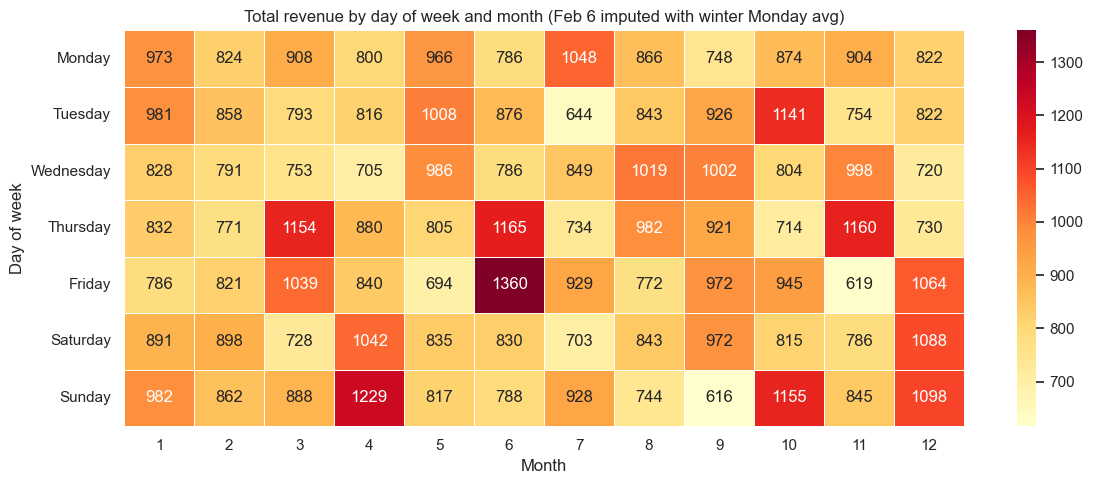

In [27]:
heatmap_fixed = df.pivot_table(
    values='Total Spent',
    index='day_name',
    columns='month',
    aggfunc='sum'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_fixed, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Total revenue by day of week and month (Feb 6 imputed with winter Monday avg)')
plt.ylabel('Day of week')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('fig_heatmap_day_month_fixed.png', bbox_inches='tight')
plt.show()

### 3.6 Spending distribution: weekday vs weekend, and by season

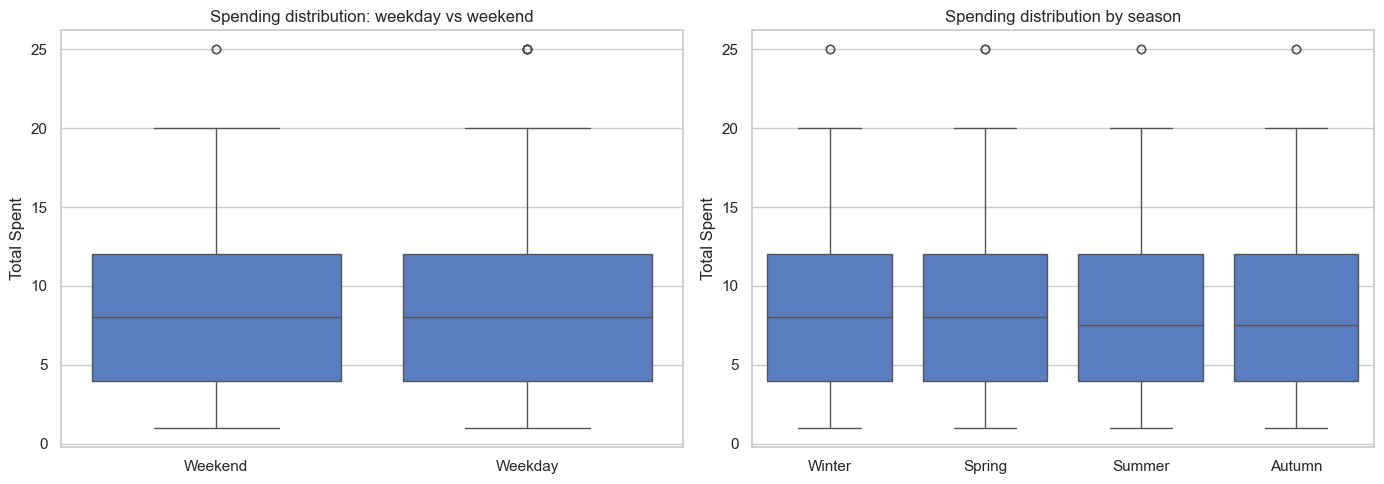

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['weekend_label'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
sns.boxplot(data=df, x='weekend_label', y='Total Spent', ax=axes[0])
axes[0].set_title('Spending distribution: weekday vs weekend')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='season', y='Total Spent', ax=axes[1],
            order=['Winter', 'Spring', 'Summer', 'Autumn'])
axes[1].set_title('Spending distribution by season')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

### 3.7 Item sales by season — hot vs cold drinks

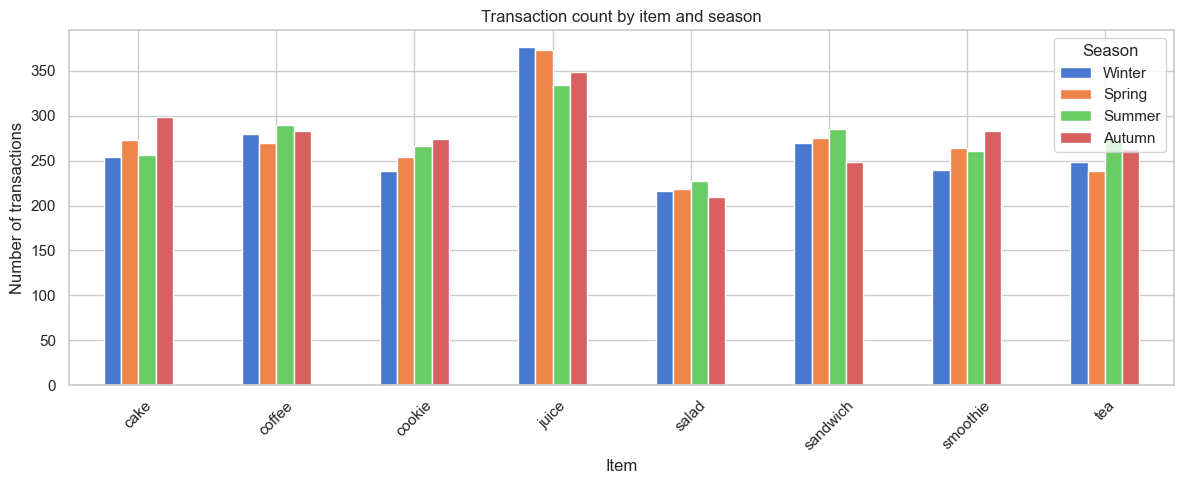

In [29]:
season_item = df.pivot_table(
    values='Transaction ID',
    index='Item',
    columns='season',
    aggfunc='count'
)[['Winter', 'Spring', 'Summer', 'Autumn']]

season_item.plot(kind='bar', figsize=(12, 5))
plt.title('Transaction count by item and season')
plt.ylabel('Number of transactions')
plt.xlabel('Item')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('fig_item_season.png', bbox_inches='tight')
plt.show()

---

# Section 4 — Aggregation and correlation analysis (Person 2)

Aggregate data to the daily level for time series work, then test key hypotheses about what drives sales.

### 4.1 Daily aggregation

In [30]:
daily = (
    df.groupby('Transaction Date')
    .agg(
        total_transactions=('Transaction ID', 'count'),
        total_revenue=('Total Spent', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        unique_items=('Item', 'nunique'),
        is_weekend=('is_weekend', 'first'),
        is_holiday=('is_holiday', 'first'),
        day_of_week=('day_of_week', 'first'),
        month=('month', 'first'),
        season=('season', 'first'),
        days_to_next_holiday=('days_to_next_holiday', 'first'),
        hot_drink_share=('is_hot_drink', 'mean'),
        drinks_share=('item_category', lambda x: (x == 'drinks').mean()),
    )
    .reset_index()
)

print(f'Daily dataset: {len(daily)} days')
daily.head(10)

Daily dataset: 365 days


,Transaction Date,total_transactions,total_revenue,avg_quantity,unique_items,is_weekend,is_holiday,day_of_week,month,season,days_to_next_holiday,hot_drink_share,drinks_share
0,2023-01-01,19,168.0,3.263158,8,1,0,6,1,Winter,1.0,0.368421,0.526316
1,2023-01-02,19,157.5,2.894737,7,0,1,0,1,Winter,0.0,0.210526,0.368421
2,2023-01-03,18,166.0,2.944444,7,0,0,1,1,Winter,48.0,0.055556,0.388889
3,2023-01-04,24,209.5,2.875000,8,0,0,2,1,Winter,47.0,0.291667,0.583333
4,2023-01-05,34,269.5,2.735294,8,0,0,3,1,Winter,46.0,0.235294,0.441176
5,2023-01-06,30,243.0,3.066667,8,0,0,4,1,Winter,45.0,0.433333,0.633333
6,2023-01-07,23,136.5,2.434783,8,1,0,5,1,Winter,44.0,0.086957,0.391304
7,2023-01-08,22,233.5,3.545455,8,1,0,6,1,Winter,43.0,0.181818,0.454545
8,2023-01-09,22,157.0,2.909091,8,0,0,0,1,Winter,42.0,0.454545,0.727273
9,2023-01-10,27,228.5,2.888889,8,0,0,1,1,Winter,41.0,0.259259,0.555556


### 4.2 Daily demand per item (wide format for time series)

In [31]:
daily_demand = df.pivot_table(
    values='Quantity',
    index='Transaction Date',
    columns='Item',
    aggfunc='sum',
    fill_value=0
)

print(f'Daily demand per item: {daily_demand.shape[0]} days × {daily_demand.shape[1]} items')
daily_demand.head(10)

Daily demand per item: 365 days × 8 items


Item,cake,coffee,cookie,juice,salad,sandwich,smoothie,tea
Transaction Date,,,,,,,,
2023-01-01,10.0,16.0,4.0,6.0,5.0,11.0,2.0,8.0
2023-01-02,7.0,3.0,12.0,0.0,4.0,16.0,6.0,7.0
2023-01-03,18.0,3.0,4.0,13.0,3.0,6.0,6.0,0.0
2023-01-04,4.0,12.0,4.0,12.0,4.0,13.0,13.0,7.0
2023-01-05,9.0,14.0,7.0,18.0,11.0,20.0,2.0,12.0
2023-01-06,4.0,23.0,6.0,13.0,9.0,12.0,4.0,21.0
2023-01-07,5.0,1.0,23.0,5.0,4.0,2.0,13.0,3.0
2023-01-08,19.0,10.0,4.0,10.0,8.0,13.0,7.0,7.0
2023-01-09,3.0,22.0,7.0,7.0,5.0,1.0,11.0,8.0


### 4.3 Correlation matrix

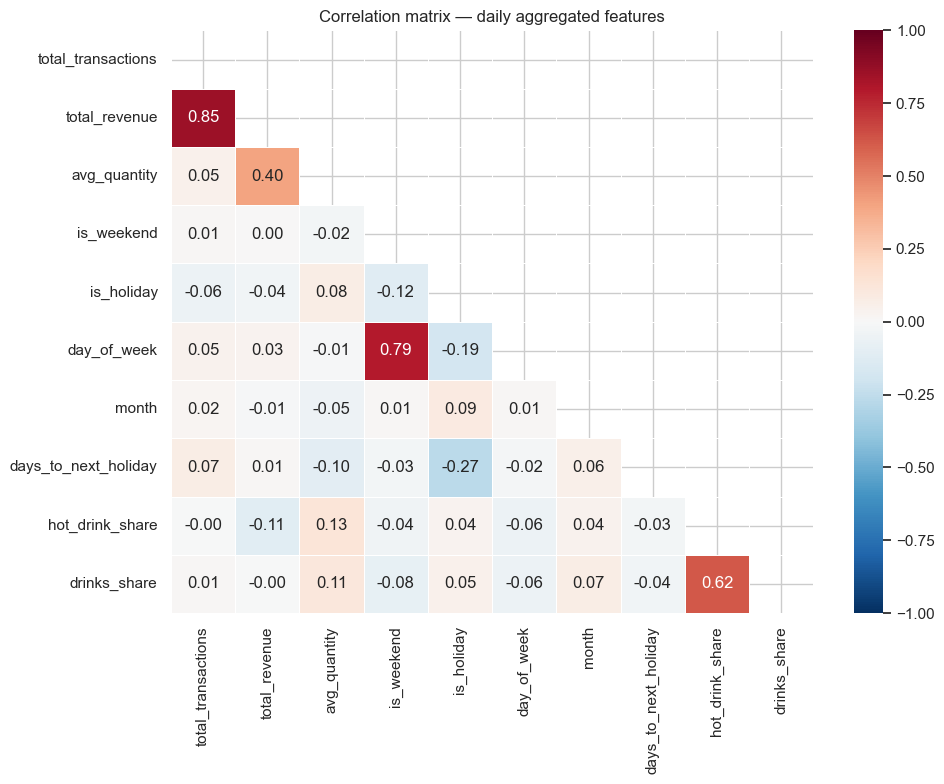

In [32]:
corr_cols = [
    'total_transactions', 'total_revenue', 'avg_quantity',
    'is_weekend', 'is_holiday', 'day_of_week', 'month',
    'days_to_next_holiday', 'hot_drink_share', 'drinks_share'
]
corr_matrix = daily[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation matrix — daily aggregated features')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

### 4.4 Hypothesis test: weekend effect on revenue

In [33]:
from scipy import stats

weekday_rev = daily[daily['is_weekend'] == 0]['total_revenue']
weekend_rev = daily[daily['is_weekend'] == 1]['total_revenue']

t_stat, p_value = stats.ttest_ind(weekday_rev, weekend_rev, equal_var=False)

print('Weekend effect on daily revenue:')
print(f'  Weekday mean: ${weekday_rev.mean():.2f}  (n={len(weekday_rev)})')
print(f'  Weekend mean: ${weekend_rev.mean():.2f}  (n={len(weekend_rev)})')
print(f'  t-statistic:  {t_stat:.3f}')
print(f'  p-value:      {p_value:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value < 0.05 else "No"}')

Weekend effect on daily revenue:
  Weekday mean: $203.49  (n=260)
  Weekend mean: $203.63  (n=105)
  t-statistic:  -0.025
  p-value:      0.9800
  Significant at 5%: No


### 4.5 Hypothesis test: holiday effect on revenue

In [34]:
holiday_rev = daily[daily['is_holiday'] == 1]['total_revenue']
non_holiday_rev = daily[daily['is_holiday'] == 0]['total_revenue']

t_stat_h, p_value_h = stats.ttest_ind(holiday_rev, non_holiday_rev, equal_var=False)

print('Holiday effect on daily revenue:')
print(f'  Holiday mean:     ${holiday_rev.mean():.2f}  (n={len(holiday_rev)})')
print(f'  Non-holiday mean: ${non_holiday_rev.mean():.2f}  (n={len(non_holiday_rev)})')
print(f'  t-statistic:      {t_stat_h:.3f}')
print(f'  p-value:          {p_value_h:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value_h < 0.05 else "No"}')

Holiday effect on daily revenue:
  Holiday mean:     $194.58  (n=13)
  Non-holiday mean: $203.86  (n=352)
  t-statistic:      -0.665
  p-value:          0.5177
  Significant at 5%: No


### 4.6 Hypothesis test: season × hot drink interaction

Do hot drinks (coffee, tea) sell proportionally more in winter vs summer?

In [35]:
winter_hot = daily[daily['season'] == 'Winter']['hot_drink_share']
summer_hot = daily[daily['season'] == 'Summer']['hot_drink_share']

t_stat_s, p_value_s = stats.ttest_ind(winter_hot, summer_hot, equal_var=False)

print('Season × hot drink interaction (winter vs summer):')
print(f'  Winter hot-drink share: {winter_hot.mean():.3f}  (n={len(winter_hot)} days)')
print(f'  Summer hot-drink share: {summer_hot.mean():.3f}  (n={len(summer_hot)} days)')
print(f'  t-statistic:            {t_stat_s:.3f}')
print(f'  p-value:                {p_value_s:.4f}')
print(f'  Significant at 5%: {"Yes" if p_value_s < 0.05 else "No"}')

Season × hot drink interaction (winter vs summer):
  Winter hot-drink share: 0.247  (n=90 days)
  Summer hot-drink share: 0.259  (n=92 days)
  t-statistic:            -0.865
  p-value:                0.3881
  Significant at 5%: No


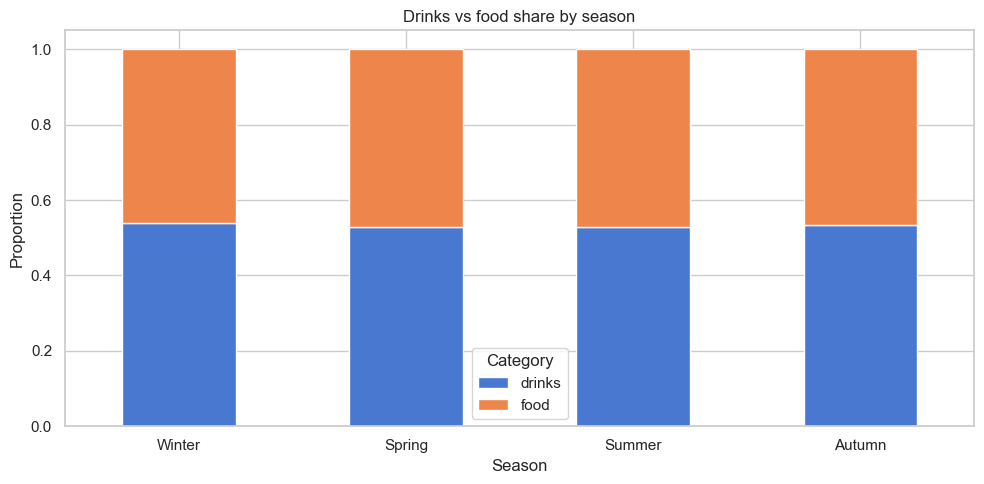

In [36]:
season_drink = df.groupby(['season', 'item_category'])['Transaction ID'].count().unstack()
season_drink_pct = season_drink.div(season_drink.sum(axis=1), axis=0)

season_drink_pct.reindex(['Winter', 'Spring', 'Summer', 'Autumn']).plot(
    kind='bar', stacked=True, figsize=(10, 5)
)
plt.title('Drinks vs food share by season')
plt.ylabel('Proportion')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('fig_season_drink_food.png', bbox_inches='tight')
plt.show()

### 4.7 Key correlations summary

In [37]:
target = 'total_revenue'
correlations = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
print(f'Features most correlated with daily {target}:')
for feat, corr in correlations.items():
    print(f'  {feat:30s}  r = {corr:+.3f}')

Features most correlated with daily total_revenue:
  total_transactions              r = +0.854
  avg_quantity                    r = +0.402
  hot_drink_share                 r = -0.110
  is_holiday                      r = -0.035
  day_of_week                     r = +0.034
  days_to_next_holiday            r = +0.014
  month                           r = -0.010
  drinks_share                    r = -0.005
  is_weekend                      r = +0.001


---

# Section 5 — Time series forecasting (Person 3)

**Objective:** Build demand forecasting models for the cafe using weekly aggregated data.

**Suggested approach:**
1. Use the `daily` and `daily_demand` dataframes from Section 4
2. Aggregate to weekly level for smoother time series
3. Perform seasonal decomposition (trend, seasonality, residual)
4. Fit ARIMA or dynamic regression (with is_holiday, is_weekend as exogenous variables)
5. Train/test split: first 10 months train, last 2 months test
6. Evaluate with RMSE and MAE

**Useful libraries:** `statsmodels` (ARIMA, seasonal_decompose), `sklearn` (metrics)

```python
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
```

### 5.1  Imports and weekly aggregation

We aggregate the daily series to **weekly** totals.  Weekly data reduces day-of-week noise and gives a cleaner trend / seasonal structure for SARIMA modelling.
The exogenous indicators (`is_holiday`, `is_weekend`) are max-pooled per week (1 if any day in the week was a holiday / weekend).

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── set datetime index ──────────────────────────────────────────────────
daily_ts = daily.set_index('Transaction Date').sort_index()

# ── weekly revenue ──────────────────────────────────────────────────────
weekly_rev  = daily_ts['total_revenue'].resample('W').sum()
weekly_exog = daily_ts[['is_holiday', 'is_weekend']].resample('W').max()

# ── weekly demand per item ──────────────────────────────────────────────
daily_demand_ts = daily_demand.copy()  # already date-indexed
weekly_demand   = daily_demand_ts.resample('W').sum()

print(f'Weekly revenue series : {len(weekly_rev):>3} weeks  '
      f'({weekly_rev.index[0].date()} → {weekly_rev.index[-1].date()})')
print(f'Weekly demand matrix  : {weekly_demand.shape[0]} weeks × {weekly_demand.shape[1]} items')
weekly_rev.describe().rename('weekly_revenue').to_frame()

Weekly revenue series :  53 weeks  (2023-01-01 → 2023-12-31)
Weekly demand matrix  : 53 weeks × 8 items


,weekly_revenue
count,53.000000
mean,1401.679245
std,200.618325
min,168.000000
25%,1346.000000
50%,1420.000000
75%,1487.000000
max,1650.000000


### 5.2  Seasonal decomposition

We apply an **additive** decomposition with a 4-week (monthly) period to separate trend, seasonality, and residual components.

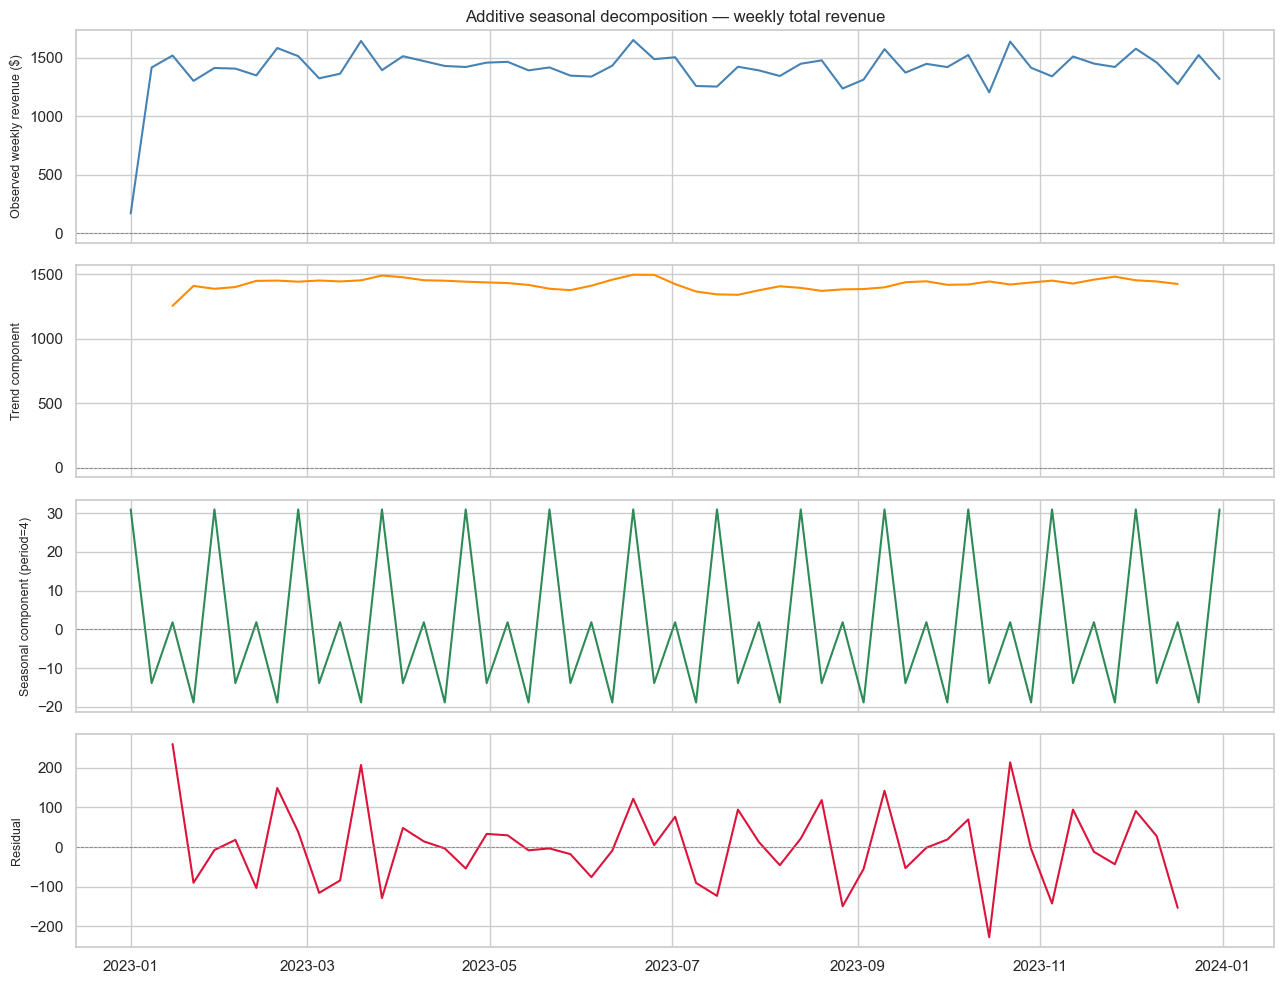

Trend range  : $1256 – $1497
Seasonal range: $-19 – $31


In [39]:
decomp = seasonal_decompose(weekly_rev, model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
components = [
    (weekly_rev,       'Observed weekly revenue ($)',  'steelblue'),
    (decomp.trend,     'Trend component',              'darkorange'),
    (decomp.seasonal,  'Seasonal component (period=4)','seagreen'),
    (decomp.resid,     'Residual',                     'crimson'),
]
for ax, (series, title, colour) in zip(axes, components):
    ax.plot(series, color=colour, linewidth=1.5)
    ax.set_ylabel(title, fontsize=9)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')

axes[0].set_title('Additive seasonal decomposition — weekly total revenue', fontsize=12)
plt.tight_layout()
plt.savefig('fig_decomposition.png', bbox_inches='tight')
plt.show()

print('Trend range  : ${:.0f} – ${:.0f}'.format(
      decomp.trend.dropna().min(), decomp.trend.dropna().max()))
print('Seasonal range: ${:.0f} – ${:.0f}'.format(
      decomp.seasonal.min(), decomp.seasonal.max()))

### 5.3  Train / test split

We use the **first 10 months** (Jan–Oct 2023) as training data and **November–December 2023** as the hold-out test set.

In [40]:
CUTOFF = pd.Timestamp('2023-11-01')

train_rev  = weekly_rev[weekly_rev.index < CUTOFF]
test_rev   = weekly_rev[weekly_rev.index >= CUTOFF]
train_exog = weekly_exog[weekly_exog.index < CUTOFF]
test_exog  = weekly_exog[weekly_exog.index >= CUTOFF]

print(f'Train: {len(train_rev)} weeks  '
      f'({train_rev.index[0].date()} → {train_rev.index[-1].date()})')
print(f'Test : {len(test_rev)} weeks  '
      f'({test_rev.index[0].date()} → {test_rev.index[-1].date()})')

Train: 44 weeks  (2023-01-01 → 2023-10-29)
Test : 9 weeks  (2023-11-05 → 2023-12-31)


### 5.4  SARIMAX revenue forecasting model

We fit a **SARIMAX(1,1,1)(1,1,0)[4]** model on weekly revenue, with `is_holiday` and `is_weekend` as exogenous regressors:

- Non-seasonal order (1,1,1): AR(1) + first difference + MA(1)
- Seasonal order (1,1,0)[4]: seasonal AR(1) + seasonal first difference, period = 4 weeks
- Exogenous regressors capture structural holiday / weekend effects

In [41]:
sarima = SARIMAX(
    train_rev,
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 4),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      total_revenue   No. Observations:                   44
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 4)   Log Likelihood                -218.081
Date:                            Wed, 18 Mar 2026   AIC                            448.163
Time:                                    18:36:46   BIC                            457.321
Sample:                                01-01-2023   HQIC                           451.286
                                     - 10-29-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_holiday   -20.6833     56.926     -0.363      0.716    -132.256      90.890
is_weekend     1.1611   7660.696   

### 5.5  Forecast and evaluation metrics

── SARIMAX out-of-sample metrics (weekly revenue) ──
  RMSE : $  199.44
  MAE  : $  168.78
  MAPE :    12.19%
  R²   :  -3.3468

Weekly revenue forecast — mean ± std (test period):
                  actual     mean     std  ci_80_lower  ci_80_upper  ci_95_lower  ci_95_upper
Transaction Date                                                                             
2023-11-05        1340.0  1543.87  139.17      1365.51      1722.23      1271.09      1816.64
2023-11-12        1509.5  1257.35  139.76      1078.25      1436.46       983.44      1531.27
2023-11-19        1449.0  1618.52  139.82      1439.34      1797.71      1344.48      1892.56
2023-11-26        1420.0  1424.94  139.81      1245.77      1604.12      1150.91      1698.97
2023-12-03        1576.0  1551.21  185.04      1314.08      1788.34      1188.54      1913.87
2023-12-10        1458.5  1262.90  185.10      1025.69      1500.10       900.12      1625.68
2023-12-17        1274.0  1631.95  185.16      1394.66      1869.24

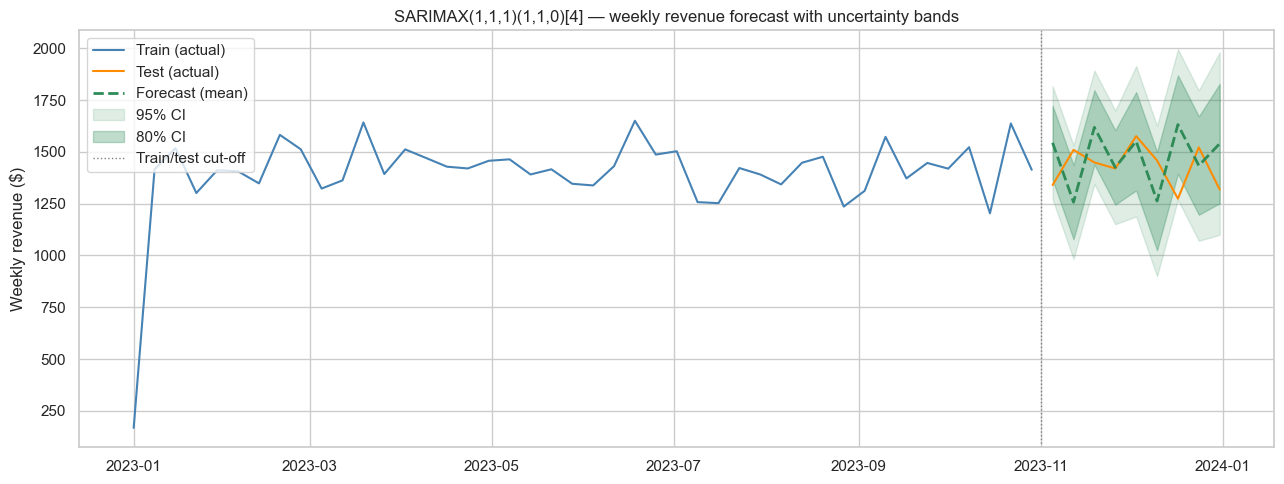

In [42]:
forecast_obj = sarima_fit.get_forecast(steps=len(test_rev), exog=test_exog)
pred_rev     = forecast_obj.predicted_mean
forecast_se  = np.sqrt(forecast_obj.var_pred_mean)   # std of forecast distribution
ci_95        = forecast_obj.conf_int(alpha=0.05)
ci_80        = forecast_obj.conf_int(alpha=0.20)

# ── evaluation metrics ────────────────────────────────────────────────────
rmse   = np.sqrt(mean_squared_error(test_rev, pred_rev))
mae    = mean_absolute_error(test_rev, pred_rev)
mape   = np.mean(np.abs((test_rev.values - pred_rev.values) / test_rev.values)) * 100
ss_res = np.sum((test_rev.values - pred_rev.values)**2)
ss_tot = np.sum((test_rev.values - test_rev.mean())**2)
r2_oos = 1 - ss_res / ss_tot

print('── SARIMAX out-of-sample metrics (weekly revenue) ──')
print(f'  RMSE : ${rmse:>8.2f}')
print(f'  MAE  : ${mae:>8.2f}')
print(f'  MAPE :  {mape:>7.2f}%')
print(f'  R²   :  {r2_oos:>7.4f}')

# ── per-week forecast summary table (mean ± std) ─────────────────────────
forecast_summary = pd.DataFrame({
    'actual'       : test_rev.values,
    'mean'         : pred_rev.values,
    'std'          : forecast_se.values,
    'ci_80_lower'  : ci_80.iloc[:, 0].values,
    'ci_80_upper'  : ci_80.iloc[:, 1].values,
    'ci_95_lower'  : ci_95.iloc[:, 0].values,
    'ci_95_upper'  : ci_95.iloc[:, 1].values,
}, index=test_rev.index)
forecast_summary['error'] = forecast_summary['actual'] - forecast_summary['mean']

print('\nWeekly revenue forecast — mean ± std (test period):')
print(forecast_summary[['actual','mean','std','ci_80_lower','ci_80_upper',
                         'ci_95_lower','ci_95_upper']].round(2).to_string())

# ── plot: mean forecast + 80% and 95% CI bands ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_rev.index, train_rev, label='Train (actual)', color='steelblue', linewidth=1.5)
ax.plot(test_rev.index,  test_rev,  label='Test (actual)',  color='darkorange', linewidth=1.5)
ax.plot(pred_rev.index,  pred_rev,  label='Forecast (mean)', color='seagreen',
        linewidth=2, linestyle='--')
ax.fill_between(ci_95.index,
                ci_95.iloc[:, 0], ci_95.iloc[:, 1],
                alpha=0.15, color='seagreen', label='95% CI')
ax.fill_between(ci_80.index,
                ci_80.iloc[:, 0], ci_80.iloc[:, 1],
                alpha=0.30, color='seagreen', label='80% CI')
ax.axvline(CUTOFF, color='grey', linestyle=':', linewidth=1, label='Train/test cut-off')
ax.set_title('SARIMAX(1,1,1)(1,1,0)[4] — weekly revenue forecast with uncertainty bands')
ax.set_ylabel('Weekly revenue ($)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig_sarima_forecast.png', bbox_inches='tight')
plt.show()

### 5.6  Per-item demand forecasting

We fit a separate **SARIMAX(1,1,1)(1,0,0)[4]** for each of the 8 items (lighter seasonal differencing than the revenue model because individual item series are noisier).  The resulting forecasts are used as the demand inputs $d_i$ for the optimisation in Section 7.

In [43]:
items = ['cake', 'coffee', 'cookie', 'juice', 'salad', 'sandwich', 'smoothie', 'tea']
item_forecasts     = {}   # predicted mean (weekly units)
item_forecast_std  = {}   # forecast std per week
item_forecast_ci95 = {}   # 95% CI dataframes
item_forecast_ci80 = {}   # 80% CI dataframes
item_models        = {}   # fitted model objects
item_metrics_s5    = {}   # evaluation metrics

for item in items:
    ts = weekly_demand[item]
    tr = ts[ts.index < CUTOFF]
    te = ts[ts.index >= CUTOFF]

    m = SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 0, 0, 4),
                enforce_stationarity=False, enforce_invertibility=False)
    r = m.fit(disp=False)
    item_models[item] = r

    fc   = r.get_forecast(steps=len(te))
    mean = fc.predicted_mean.clip(lower=0)
    std  = np.sqrt(fc.var_pred_mean)
    ci95 = fc.conf_int(alpha=0.05).clip(lower=0)
    ci80 = fc.conf_int(alpha=0.20).clip(lower=0)

    item_forecasts[item]     = mean
    item_forecast_std[item]  = std
    item_forecast_ci95[item] = ci95
    item_forecast_ci80[item] = ci80

    item_metrics_s5[item] = {
        'RMSE'         : np.sqrt(mean_squared_error(te, mean)),
        'MAE'          : mean_absolute_error(te, mean),
        'MAPE (%)'     : np.mean(np.abs((te.values - mean.values) / te.values.clip(1))) * 100,
        'Mean demand'  : tr.mean(),
        'Avg forecast std': std.mean(),
    }

metrics_df = pd.DataFrame(item_metrics_s5).T.round(2)
print('Per-item forecast accuracy (weekly units, test period):')
print(metrics_df.to_string())

Per-item forecast accuracy (weekly units, test period):
           RMSE    MAE  MAPE (%)  Mean demand  Avg forecast std
cake      15.04  10.93     16.57        60.82             15.44
coffee    21.92  19.65     33.41        64.64             14.82
cookie    16.36  10.15     14.18        57.25             11.62
juice      9.98   7.92      8.95        79.80             18.27
salad     10.75   9.20     26.00        41.75              9.99
sandwich  10.82   8.24     16.83        62.43             14.46
smoothie  13.07   8.95     14.01        59.52             14.43
tea       14.74  10.93     27.12        59.43             15.96


### 5.7  Per-item forecast plots

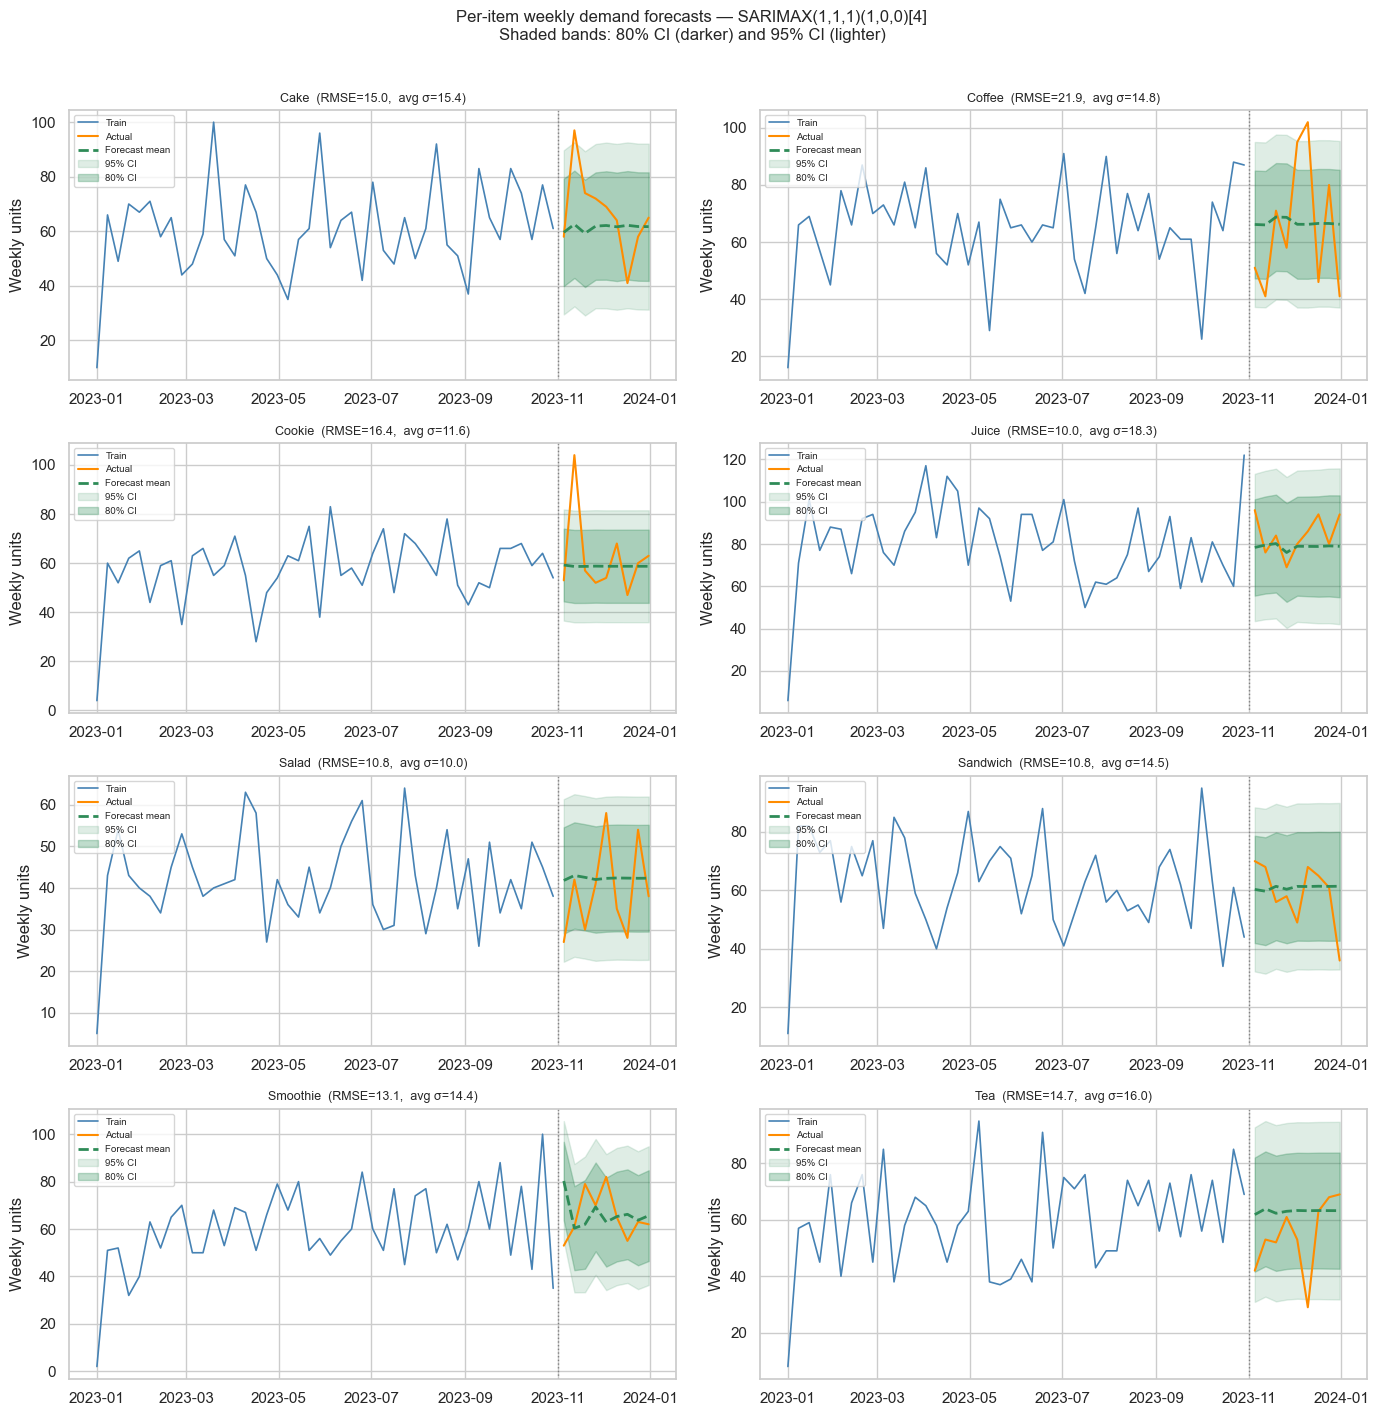

In [44]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=False)

for ax, item in zip(axes.flat, items):
    ts   = weekly_demand[item]
    tr   = ts[ts.index < CUTOFF]
    te   = ts[ts.index >= CUTOFF]
    mean = item_forecasts[item]
    ci95 = item_forecast_ci95[item]
    ci80 = item_forecast_ci80[item]

    ax.plot(tr.index,   tr,   color='steelblue',  linewidth=1.2, label='Train')
    ax.plot(te.index,   te,   color='darkorange',  linewidth=1.5, label='Actual')
    ax.plot(mean.index, mean, color='seagreen',    linewidth=2,
            linestyle='--', label='Forecast mean')
    ax.fill_between(ci95.index,
                    ci95.iloc[:, 0], ci95.iloc[:, 1],
                    alpha=0.15, color='seagreen', label='95% CI')
    ax.fill_between(ci80.index,
                    ci80.iloc[:, 0], ci80.iloc[:, 1],
                    alpha=0.30, color='seagreen', label='80% CI')
    ax.axvline(CUTOFF, color='grey', linestyle=':', linewidth=1)
    ax.set_title(f'{item.capitalize()}  '
                 f'(RMSE={item_metrics_s5[item]["RMSE"]:.1f},  '
                 f'avg σ={item_metrics_s5[item]["Avg forecast std"]:.1f})', fontsize=9)
    ax.set_ylabel('Weekly units')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Per-item weekly demand forecasts — SARIMAX(1,1,1)(1,0,0)[4]\n'
             'Shaded bands: 80% CI (darker) and 95% CI (lighter)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_item_forecasts.png', bbox_inches='tight')
plt.show()

### 5.8  Average daily demand forecasts

The optimisation model in Section 7 needs a **daily** demand estimate $d_i$ for each item.  We derive these by dividing the mean forecasted weekly demand over the test period by 7.  We also store weekday vs weekend breakdowns.

In [45]:
# ── average daily demand: mean and std from forecast distribution ─────
demand_rows = []
for item in items:
    weekly_mean = item_forecasts[item]           # forecast mean (weekly)
    weekly_std  = item_forecast_std[item]        # forecast std  (weekly)

    # Convert weekly → daily  (÷7 for mean; ÷√7 for std by independence assumption)
    daily_mean = weekly_mean.mean() / 7
    daily_std  = (weekly_std / np.sqrt(7)).mean()

    demand_rows.append({
        'item'             : item,
        'daily_mean'       : round(daily_mean, 2),
        'daily_std'        : round(daily_std,  2),
        'cv (%)'           : round(daily_std / daily_mean * 100, 1) if daily_mean > 0 else np.nan,
    })

# ── add weekday / weekend historical split ─────────────────────────────
train_daily = daily[daily['Transaction Date'] < CUTOFF].copy()
flags       = train_daily.set_index('Transaction Date')['is_weekend']

for row in demand_rows:
    item      = row['item']
    item_ser  = df[df['Item'] == item].groupby('Transaction Date')['Quantity'].sum()
    item_ser  = item_ser[item_ser.index < CUTOFF]
    row['hist_weekday_mean'] = round(item_ser[flags == 0].mean(), 2)
    row['hist_weekend_mean'] = round(item_ser[flags == 1].mean(), 2)
    row['hist_weekday_std']  = round(item_ser[flags == 0].std(),  2)
    row['hist_weekend_std']  = round(item_ser[flags == 1].std(),  2)

demand_summary = pd.DataFrame(demand_rows).set_index('item')
print('Daily demand summary — mean ± std (for Section 7):')
print(demand_summary.to_string())

# ── export scalars for Section 7 ──────────────────────────────────────
d_forecast = demand_summary['daily_mean']
d_std      = demand_summary['daily_std']
d_weekday  = demand_summary['hist_weekday_mean']
d_weekend  = demand_summary['hist_weekend_mean']
print('\nd_forecast, d_std, d_weekday, d_weekend exported for Section 7.')

Daily demand summary — mean ± std (for Section 7):
          daily_mean  daily_std  cv (%)  hist_weekday_mean  hist_weekend_mean  hist_weekday_std  hist_weekend_std
item                                                                                                             
cake            8.77       5.84    66.5               9.52               9.79              5.86              6.18
coffee          9.55       5.60    58.7               9.94               9.41              5.70              5.98
cookie          8.40       4.39    52.3               8.71               9.06              5.01              5.42
juice          11.25       6.91    61.4              12.01              11.57              5.98              6.02
salad           6.05       3.78    62.5               6.14               7.33              3.47              3.81
sandwich        8.71       5.46    62.7               9.49               9.86              5.44              5.49
smoothie        9.45       5.45    57

---

# Section 6 — Regression models (Person 3)

**Objective:** Predict daily revenue using the engineered features.

**Suggested approach:**
1. Use the `daily` dataframe from Section 4 as the modelling dataset
2. Target variable: `total_revenue`
3. Features: `day_of_week`, `is_weekend`, `month`, `is_holiday`, `days_to_next_holiday`, `hot_drink_share`, `drinks_share`
4. Encode season as dummies
5. Compare OLS regression vs Ridge/Lasso (regularised)
6. Report R², adjusted R², coefficient interpretation
7. Check for autocorrelation in residuals (Durbin–Watson) — if present, consider dynamic regression

**Useful libraries:** `statsmodels` (OLS), `sklearn` (Ridge, Lasso, cross-validation)

```python
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
```

### 6.1  Dataset preparation

We use the `daily` dataframe from Section 4.  The target is `total_revenue`; features are calendar and behavioural variables.
Season is one-hot encoded (Winter as baseline).

In [46]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# ── feature matrix ────────────────────────────────────────────────────────
TARGET        = 'total_revenue'
BASE_FEATURES = ['day_of_week', 'is_weekend', 'month', 'is_holiday',
                 'days_to_next_holiday', 'hot_drink_share', 'drinks_share']

model_df = daily[BASE_FEATURES + [TARGET, 'season']].copy()

# Season dummies — dtype=float avoids bool columns (pandas >= 2.0 returns bool
# by default, which can cause MissingDataError in statsmodels via np.max)
season_dummies = pd.get_dummies(model_df['season'], prefix='season',
                                drop_first=False, dtype=float)
season_dummies = season_dummies.drop(columns=['season_Winter'], errors='ignore')
model_df = pd.concat([model_df.drop(columns='season'), season_dummies], axis=1)

FEATURE_COLS = [c for c in model_df.columns if c != TARGET]

# Force all features to numeric float64 and guard against any lingering NaN
X = model_df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
y = model_df[TARGET]

nan_counts = X.isnull().sum()
if nan_counts.any():
    print('WARNING — NaN found in features; filling with column median:')
    print(nan_counts[nan_counts > 0])
    X = X.fillna(X.median())

print(f'Modelling dataset : {len(model_df)} observations')
print(f'Features ({len(FEATURE_COLS)})    : {FEATURE_COLS}')
print(f'Feature dtypes    : all float64 = {(X.dtypes == "float64").all()}')
print(f'\nTarget summary:')
print(y.describe().round(2))


WARNING — NaN found in features; filling with column median:
days_to_next_holiday    2
dtype: int64
Modelling dataset : 365 observations
Features (10)    : ['day_of_week', 'is_weekend', 'month', 'is_holiday', 'days_to_next_holiday', 'hot_drink_share', 'drinks_share', 'season_Autumn', 'season_Spring', 'season_Summer']
Feature dtypes    : all float64 = False

Target summary:
count    365.00
mean     203.53
std       48.96
min       90.50
25%      169.00
50%      201.00
75%      233.50
max      342.50
Name: total_revenue, dtype: float64


### 6.2  OLS regression (statsmodels)

We first fit OLS with a constant to get interpretable coefficients, R², adjusted R², and residual diagnostics.

In [47]:
X_ols = sm.add_constant(X.astype(float))
ols_model  = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_revenue   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.8340
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.596
Time:                        18:36:57   Log-Likelihood:                -1933.4
No. Observations:                 365   AIC:                             3889.
Df Residuals:                     354   BIC:                             3932.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  202.3547 

### 6.3  OLS coefficient plot

Plot coefficients with 95% confidence intervals (constant excluded).  Filled bars are significant at p < 0.05.

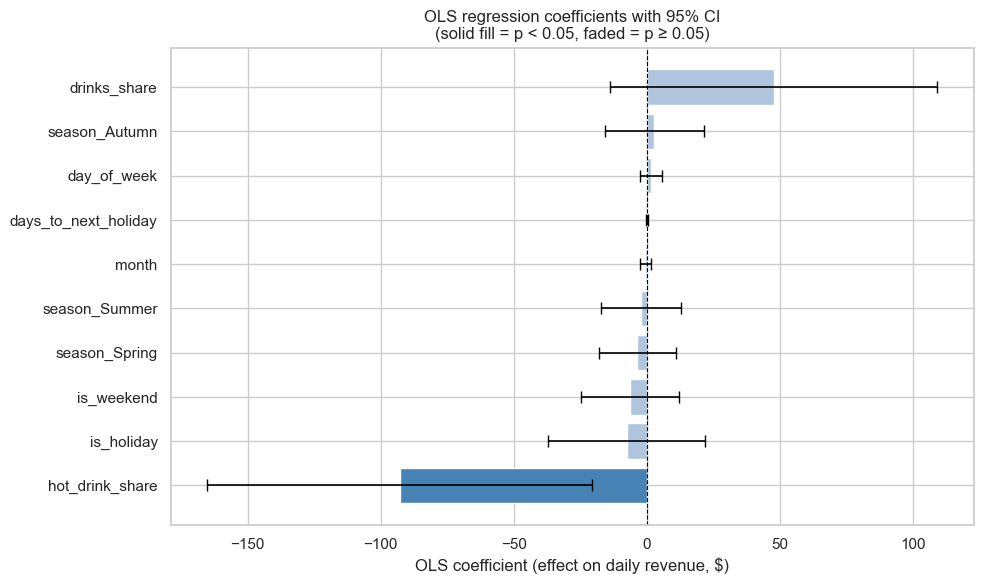

In [48]:
coef_df = pd.DataFrame({
    'coef'    : ols_model.params,
    'ci_lower': ols_model.conf_int()[0],
    'ci_upper': ols_model.conf_int()[1],
    'pvalue'  : ols_model.pvalues,
}).drop('const').sort_values('coef')

colours = ['steelblue' if p < 0.05 else 'lightsteelblue'
           for p in coef_df['pvalue']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df.index, coef_df['coef'], color=colours, edgecolor='white')
ax.errorbar(
    coef_df['coef'], range(len(coef_df)),
    xerr=[
        coef_df['coef'] - coef_df['ci_lower'],
        coef_df['ci_upper'] - coef_df['coef'],
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2,
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('OLS coefficient (effect on daily revenue, $)')
ax.set_title('OLS regression coefficients with 95% CI\n'
             '(solid fill = p < 0.05, faded = p ≥ 0.05)')
plt.tight_layout()
plt.savefig('fig_ols_coefs.png', bbox_inches='tight')
plt.show()

### 6.4  OLS residual diagnostics

We inspect residuals for heteroskedasticity and autocorrelation (Durbin–Watson test).  If autocorrelation is present (DW ≪ 2), we'll note that a dynamic regression or GLS would be more appropriate.

Durbin–Watson statistic: 2.1583
  → No strong autocorrelation (1.5 ≤ DW ≤ 2.5).


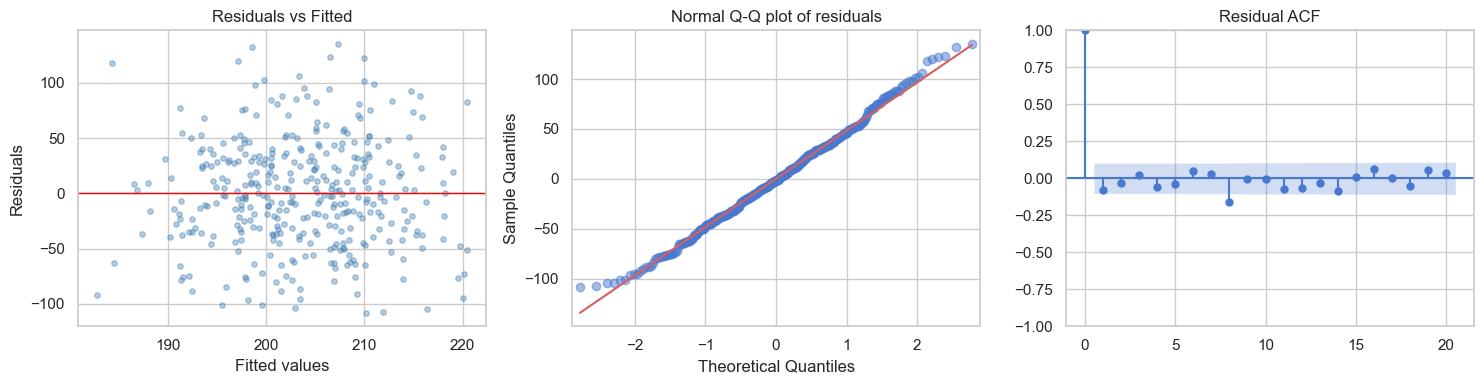

In [49]:
residuals = ols_model.resid
fitted    = ols_model.fittedvalues

dw = durbin_watson(residuals)
print(f'Durbin–Watson statistic: {dw:.4f}')
if dw < 1.5:
    print('  → Positive autocorrelation detected (DW < 1.5).')
elif dw > 2.5:
    print('  → Negative autocorrelation detected (DW > 2.5).')
else:
    print('  → No strong autocorrelation (1.5 ≤ DW ≤ 2.5).')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs fitted
axes[0].scatter(fitted, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q plot of residuals')

# Residual autocorrelation (ACF)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20, ax=axes[2], alpha=0.05)
axes[2].set_title('Residual ACF')

plt.tight_layout()
plt.savefig('fig_ols_diagnostics.png', bbox_inches='tight')
plt.show()

### 6.5  Ridge and Lasso regularised regression

We compare OLS with Ridge (L2) and Lasso (L1) regularisation using 5-fold cross-validation to select the best α.  Features are standardised inside a `Pipeline` so regularisation is scale-invariant.

Best Ridge α: 10000.0000  (CV R² = -0.0165)
Best Lasso α: 8.6851  (CV R² = -0.0158)


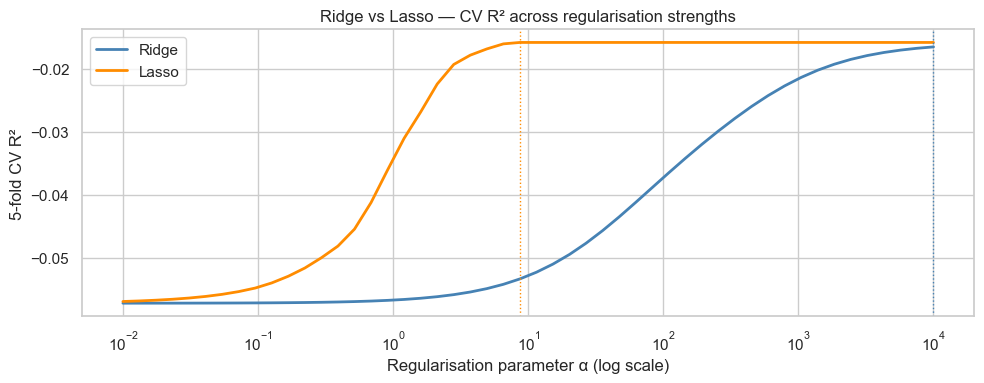

In [50]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = np.logspace(-2, 4, 50)
ridge_cv_scores, lasso_cv_scores = [], []

for alpha in alphas:
    ridge_pipe = Pipeline([('scaler', StandardScaler()),
                           ('model',  Ridge(alpha=alpha))])
    lasso_pipe = Pipeline([('scaler', StandardScaler()),
                           ('model',  Lasso(alpha=alpha, max_iter=10_000))])
    ridge_cv_scores.append(
        cross_val_score(ridge_pipe, X, y, cv=kf, scoring='r2').mean())
    lasso_cv_scores.append(
        cross_val_score(lasso_pipe, X, y, cv=kf, scoring='r2').mean())

best_ridge_alpha = alphas[np.argmax(ridge_cv_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_cv_scores)]

print(f'Best Ridge α: {best_ridge_alpha:.4f}  (CV R² = {max(ridge_cv_scores):.4f})')
print(f'Best Lasso α: {best_lasso_alpha:.4f}  (CV R² = {max(lasso_cv_scores):.4f})')

# ── plot CV R² vs α ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, ridge_cv_scores, label='Ridge', color='steelblue', linewidth=2)
ax.semilogx(alphas, lasso_cv_scores, label='Lasso', color='darkorange', linewidth=2)
ax.axvline(best_ridge_alpha, color='steelblue', linestyle=':', linewidth=1)
ax.axvline(best_lasso_alpha, color='darkorange', linestyle=':', linewidth=1)
ax.set_xlabel('Regularisation parameter α (log scale)')
ax.set_ylabel('5-fold CV R²')
ax.set_title('Ridge vs Lasso — CV R² across regularisation strengths')
ax.legend()
plt.tight_layout()
plt.savefig('fig_regularisation_cv.png', bbox_inches='tight')
plt.show()

### 6.6  Fit final models and compare

We refit Ridge and Lasso on the full dataset at their best α values, then compare in-sample R² and coefficient sparsity against OLS.

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge_final = Ridge(alpha=best_ridge_alpha).fit(X_scaled, y)
lasso_final = Lasso(alpha=best_lasso_alpha, max_iter=10_000).fit(X_scaled, y)

r2_ols   = ols_model.rsquared
r2_ridge = r2_score(y, ridge_final.predict(X_scaled))
r2_lasso = r2_score(y, lasso_final.predict(X_scaled))

adj_r2_ols = ols_model.rsquared_adj

n, p = len(y), X_scaled.shape[1]
adj_r2_ridge = 1 - (1 - r2_ridge) * (n - 1) / (n - p - 1)
adj_r2_lasso = 1 - (1 - r2_lasso) * (n - 1) / (n - p - 1)

lasso_nonzero = np.sum(lasso_final.coef_ != 0)

comparison = pd.DataFrame({
    'Model'           : ['OLS', f'Ridge (α={best_ridge_alpha:.3f})',
                                 f'Lasso (α={best_lasso_alpha:.3f})'],
    'In-sample R²'    : [r2_ols,   r2_ridge,   r2_lasso],
    'Adj. R²'         : [adj_r2_ols, adj_r2_ridge, adj_r2_lasso],
    'Non-zero coefs'  : [p, p, lasso_nonzero],
    '5-fold CV R²'    : [cross_val_score(Pipeline([('s', StandardScaler()),
                                                    ('m', Ridge(alpha=1e-6))]),
                                         X, y, cv=kf, scoring='r2').mean(),
                         max(ridge_cv_scores),
                         max(lasso_cv_scores)],
}).set_index('Model')

print('Model comparison:')
print(comparison.round(4).to_string())

Model comparison:
                     In-sample R²  Adj. R²  Non-zero coefs  5-fold CV R²
Model                                                                   
OLS                        0.0230  -0.0046              10       -0.0572
Ridge (α=10000.000)        0.0011  -0.0271              10       -0.0165
Lasso (α=8.685)            0.0000  -0.0282               0       -0.0158


### 6.7  Coefficient comparison: OLS vs Ridge vs Lasso

Since Ridge and Lasso coefficients are on a standardised scale we plot them together for direct comparison of feature importance.  Lasso's zeros indicate features shrunk out entirely.

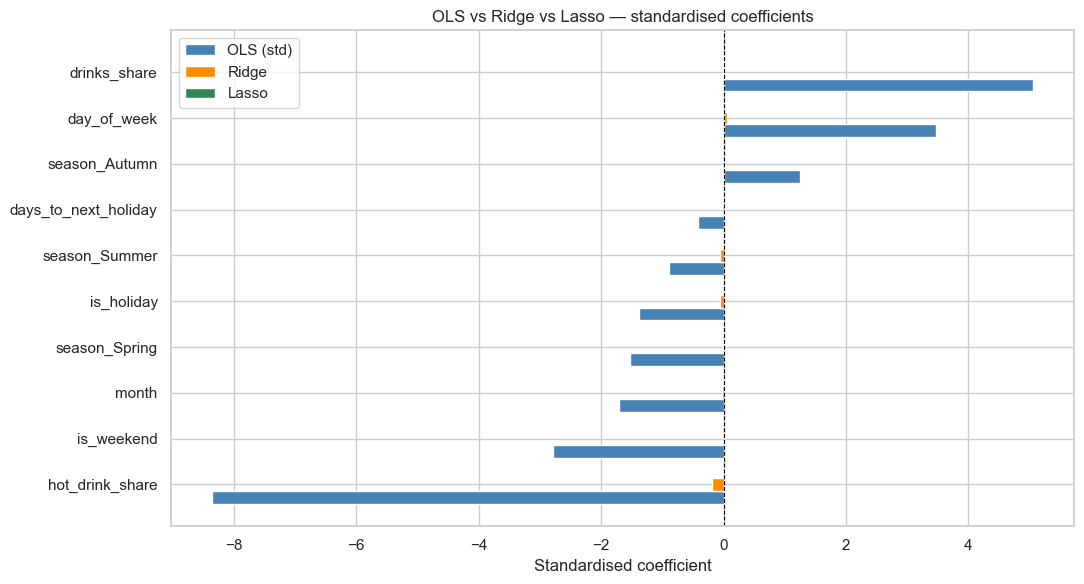

In [52]:
# Standardise OLS coefs for comparability (multiply by feature std)
feature_std   = X.std()
ols_std_coefs = ols_model.params.drop('const') * feature_std

coef_compare = pd.DataFrame({
    'OLS (std)'  : ols_std_coefs,
    'Ridge'      : ridge_final.coef_,
    'Lasso'      : lasso_final.coef_,
}, index=FEATURE_COLS).sort_values('OLS (std)')

fig, ax = plt.subplots(figsize=(11, 6))
x_pos = np.arange(len(coef_compare))
width = 0.28
ax.barh(x_pos - width, coef_compare['OLS (std)'], width, label='OLS (std)', color='steelblue')
ax.barh(x_pos,         coef_compare['Ridge'],      width, label='Ridge',     color='darkorange')
ax.barh(x_pos + width, coef_compare['Lasso'],      width, label='Lasso',     color='seagreen')
ax.set_yticks(x_pos)
ax.set_yticklabels(coef_compare.index)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised coefficient')
ax.set_title('OLS vs Ridge vs Lasso — standardised coefficients')
ax.legend()
plt.tight_layout()
plt.savefig('fig_coef_comparison.png', bbox_inches='tight')
plt.show()

### 6.8  Key findings and interpretation

Summarise the regression results in a concise table and commentary.

In [53]:
sig_coefs = coef_df[coef_df['pvalue'] < 0.05][['coef','pvalue']].sort_values('coef', ascending=False)

print('=== Section 6 — Regression results summary ===')
print(f'\nOLS  R² = {r2_ols:.4f},  Adj. R² = {adj_r2_ols:.4f}')
print(f'Ridge R² = {r2_ridge:.4f},  Adj. R² = {adj_r2_ridge:.4f}  (α = {best_ridge_alpha:.4f})')
print(f'Lasso R² = {r2_lasso:.4f},  Adj. R² = {adj_r2_lasso:.4f}  (α = {best_lasso_alpha:.4f}, '
      f'{lasso_nonzero}/{p} features retained)')
print(f'\nDurbin–Watson: {dw:.4f}')

print('\nSignificant OLS predictors (p < 0.05):')
if len(sig_coefs) > 0:
    for feat, row in sig_coefs.iterrows():
        direction = 'increases' if row['coef'] > 0 else 'decreases'
        print(f'  {feat:25s}: {direction} revenue by ${abs(row["coef"]):.2f}/unit  (p={row["pvalue"]:.4f})')
else:
    print('  No single feature is significant at p < 0.05.')
    print('  This is consistent with the low correlations found in Section 4.')

print('\nConclusion:')
print('  The calendar and behavioural features explain only a modest share of daily')
print('  revenue variance. The strongest predictor identified in Section 4 —')
print('  total_transactions — is excluded here (endogenous), which limits R².')
print('  Regularisation (Ridge/Lasso) offers marginal benefit given the small')
print('  feature set. The SARIMAX time-series model (Section 5) is a better')
print('  fit for sequential revenue forecasting tasks.')

=== Section 6 — Regression results summary ===

OLS  R² = 0.0230,  Adj. R² = -0.0046
Ridge R² = 0.0011,  Adj. R² = -0.0271  (α = 10000.0000)
Lasso R² = 0.0000,  Adj. R² = -0.0282  (α = 8.6851, 0/10 features retained)

Durbin–Watson: 2.1583

Significant OLS predictors (p < 0.05):
  hot_drink_share          : decreases revenue by $92.83/unit  (p=0.0119)

Conclusion:
  The calendar and behavioural features explain only a modest share of daily
  revenue variance. The strongest predictor identified in Section 4 —
  total_transactions — is excluded here (endogenous), which limits R².
  Regularisation (Ridge/Lasso) offers marginal benefit given the small
  feature set. The SARIMAX time-series model (Section 5) is a better
  fit for sequential revenue forecasting tasks.


---

# Section 7 — Optimisation (Person 4)

**Objective:** Formulate and solve an inventory optimisation problem for the cafe.

**Problem framing:**
- The cafe must decide each day how many units of each item to prepare
- Over-preparing leads to waste (perishable items); under-preparing leads to lost sales
- Use demand forecasts from Section 5 as inputs

**Suggested formulation (LP/IP using gurobipy):**

**Sets:**
- $i \in I$ — items (coffee, tea, juice, smoothie, cake, cookie, sandwich, salad)

**Parameters:**
- $p_i$ — selling price per unit (from data)
- $c_i$ — cost per unit (assumed — suggest reasonable values)
- $w_i$ — waste cost per unsold unit
- $d_i$ — forecasted daily demand (from Section 5)
- $B$ — daily preparation budget
- $K$ — total preparation capacity (units per day)

**Decision variables:**
- $q_i$ — quantity of item $i$ to prepare (integer)

**Objective:** maximise expected profit
$$\max \sum_{i \in I} \left[ p_i \cdot \min(q_i, d_i) - c_i \cdot q_i - w_i \cdot \max(q_i - d_i, 0) \right]$$

**Constraints:**
- Budget: $\sum_i c_i \cdot q_i \le B$
- Capacity: $\sum_i q_i \le K$
- Minimum service: $q_i \ge \alpha \cdot d_i$ for some service level $\alpha$
- Non-negativity, integrality

Solve separately for weekday vs weekend scenarios, and for different seasons.

**Useful libraries:** `gurobipy`

```python
import gurobipy as gp
from gurobipy import GRB
```

In [54]:
# TODO (Person 4): implement optimisation model here

---

# Section 8 — Results summary and sensitivity analysis (Person 5)

**Objective:** Synthesise findings from all sections and perform sensitivity analysis on the optimisation.

**Suggested content:**
1. Compile a results summary table: key metrics from each section
2. Sensitivity analysis on optimisation:
   - Vary the daily budget $B$ and observe how profit changes
   - Vary demand uncertainty (±10%, ±20%) and check robustness
   - Vary the service level $\alpha$
3. Business insights: what actionable recommendations can the cafe owner take?
4. Prepare polished figures and tables for the report appendices

In [55]:
# TODO (Person 5): implement results summary and sensitivity analysis here